# GPR — preview: mean + actual-coloured points, and \(\sigma\) (STD) surface

Reuses the saved artifacts in `OUTPUT_FOLDER` (no re-fit) and mirrors the surface
machinery of `GPR_plotting.ipynb` cell 18.

* **(a)** predicted-mean \(\langle\Delta\gamma\rangle\) surface with the training points
  coloured by their **actual** \(\Delta\gamma\) on the *same* Blues scale — they blend in
  where the model agrees and stand out where it differs.
* **(b)** predictive **standard deviation** \(\sigma_{\Delta\gamma}\) surface.

Figures are also written to `PREVIEW_DIFF_STD/`.

In [1]:
import os, json, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import thermoift.PLOT_SETTINGS as ps
from matplotlib.ticker import AutoMinorLocator
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy.spatial import Delaunay
from scipy.interpolate import (interp1d, PchipInterpolator,
                               CloughTocher2DInterpolator, NearestNDInterpolator)

In [2]:
OUTPUT_FOLDER = "SLURM_GPR_residual_5000"
PREVIEW       = "PREVIEW_DIFF_STD"
STD_CMAP      = "Blues"            # flipped: high sigma = dark
SIGMA_VMIN, SIGMA_VMAX = 0.0, 2.5  # shared sigma range (match make_shared_colorbar.py)

In [3]:
# ---- load artifacts (mirror GPR_plotting cell 4) -----------------------------
meta      = json.load(open(os.path.join(OUTPUT_FOLDER, "GPR_artifacts_meta.json")))
features  = meta["features"]; target = meta["target"]
gpr_model = joblib.load(os.path.join(OUTPUT_FOLDER, "GPR_residual_model.joblib"))
df        = pd.read_parquet(os.path.join(OUTPUT_FOLDER, "GPR_df_full.parquet"))
train_idx = np.load(os.path.join(OUTPUT_FOLDER, "GPR_splits.npz"))["train_idx"]
X_train   = df.loc[train_idx, features]
y_train   = df.loc[train_idx, target]
T_tr, P_tr = X_train["T"].values, X_train["P"].values

In [4]:
# ---- phase envelope (cross-composition max P_bubble / P_dew) -----------------
df_env_full = pd.read_csv("../../interfacial_results_dataset_A4.csv")
df_max = (df_env_full.groupby("temperature")[["P_bubble", "P_dew"]]
                     .max().reset_index().sort_values("temperature").dropna())
df_env = df_max.iloc[:-1].copy()
T_env, P_bub_env, P_dew_env = (df_env["temperature"].values,
                               df_env["P_bubble"].values, df_env["P_dew"].values)
bub = PchipInterpolator(T_env, P_bub_env, extrapolate=True)   # smooth, monotone (no kinks)
dew = PchipInterpolator(T_env, P_dew_env, extrapolate=True)

In [5]:
# ---- coarse grid + valid-domain mask; predict mean AND std -------------------
n_grid = 120
T_vals = np.linspace(T_tr.min(), T_tr.max(), n_grid)
P_vals = np.linspace(P_tr.min(), P_tr.max(), n_grid)
TT, PP = np.meshgrid(T_vals, P_vals)
hull   = Delaunay(np.column_stack([T_tr, P_tr]))
in_hull = hull.find_simplex(np.column_stack([TT.ravel(), PP.ravel()])) >= 0
in_env  = (PP.ravel() <= bub(TT.ravel())) & (PP.ravel() >= dew(TT.ravel()))
mask    = (in_hull & in_env).reshape(n_grid, n_grid)

T_idx, P_idx = features.index("T"), features.index("P")
X_grid = np.tile(X_train.median().values.copy(), (n_grid * n_grid, 1))
X_grid[:, T_idx] = TT.ravel(); X_grid[:, P_idx] = PP.ravel()

# Pipeline forwards return_std to the GaussianProcessRegressor step
mean_flat, std_flat = gpr_model.predict(pd.DataFrame(X_grid, columns=features), return_std=True)

In [6]:
# ---- dense smooth grid + field builder ---------------------------------------
n_smooth = 500
T_s = np.linspace(T_tr.min(), T_tr.max(), n_smooth)
P_s = np.linspace(P_tr.min(), P_tr.max(), n_smooth)
TT_s, PP_s = np.meshgrid(T_s, P_s)
in_hull_s = hull.find_simplex(np.column_stack([TT_s.ravel(), PP_s.ravel()])) >= 0
in_env_s  = (PP_s.ravel() <= bub(TT_s.ravel())) & (PP_s.ravel() >= dew(TT_s.ravel()))
mask_s    = (in_hull_s & in_env_s).reshape(n_smooth, n_smooth)

def make_field(flat):
    g = flat.reshape(n_grid, n_grid).astype(float); g[~mask] = np.nan
    pts = np.column_stack([TT[~np.isnan(g)], PP[~np.isnan(g)]]); vals = g[~np.isnan(g)]
    ct, nn = CloughTocher2DInterpolator(pts, vals), NearestNDInterpolator(pts, vals)
    Z = ct(TT_s, PP_s); holes = np.isnan(Z); Z[holes] = nn(TT_s[holes], PP_s[holes])
    Zc = np.ma.masked_invalid(np.where(mask_s, Z, np.nan))
    return Z, Zc

Z_mean, Zc_mean = make_field(mean_flat)
Z_std,  Zc_std  = make_field(std_flat)

In [7]:
# ---- envelope clip polygon ---------------------------------------------------
clip_T = np.concatenate([T_s, T_s[::-1]])
clip_P = np.concatenate([bub(T_s), dew(T_s)[::-1]])
clip_path = Path(np.column_stack([clip_T, clip_P]), closed=True)

def _clip(artist, patch):
    try: artist.set_clip_path(patch)
    except AttributeError:
        for coll in getattr(artist, "collections", []): coll.set_clip_path(patch)

In [8]:
def render(Z, Zc, cmap, vmin, vmax, clabel, fname, ticks=None, extend="both",
           pts_vals=None, show_cbar=True):
    fig, ax = ps.plot_init(w=6, h=4.5)
    patch = PathPatch(clip_path, facecolor="none", edgecolor="none", transform=ax.transData)
    ax.add_patch(patch)
    pcm = ax.pcolormesh(TT_s, PP_s, Z, cmap=cmap, vmin=vmin, vmax=vmax,
                        shading="gouraud", zorder=1); _clip(pcm, patch)
    if pts_vals is not None:                       # points coloured by ACTUAL value, same scale
        sc = ax.scatter(T_tr, P_tr, c=pts_vals, cmap=cmap, vmin=vmin, vmax=vmax,
                        s=9, edgecolors="0.15", linewidths=0.3, zorder=5); _clip(sc, patch)
    cs = ax.contour(TT_s, PP_s, Zc, levels=np.linspace(vmin, vmax, 9),
                    colors="black", linewidths=0.9, zorder=6); _clip(cs, patch)
    cs.set_path_effects([pe.withStroke(linewidth=2.0, foreground="white")])  # halo: visible over points & dark bands
    lbls = ax.clabel(cs, inline=True, inline_spacing=3, fontsize=ps.label_fontsize * 0.65,
                     fmt=lambda v: f"${v:.2g}$")   # math mode -> LaTeX-rendered numbers
    plt.setp(lbls, path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
    ax.plot(T_s, bub(T_s), "-", color="k", lw=ps.linewidth, zorder=7)
    ax.plot(T_s, dew(T_s), "-", color="k", lw=ps.linewidth, zorder=7)
    if show_cbar:
        cbar = fig.colorbar(pcm, ax=ax, pad=0.02, extend=extend)
        cbar.set_label(clabel, fontsize=ps.label_fontsize * 1.5)
        cbar.ax.tick_params(labelsize=ps.label_fontsize * 1.3); ps.style_colorbar(cbar)
        if ticks is not None: cbar.set_ticks(ticks)
    ax.set_xlabel(r"$T\ /\ [\mathrm{K}]$", fontsize=ps.label_fontsize * 1.5)
    ax.set_ylabel(r"$P\ /\ [\mathrm{bar}]$", fontsize=ps.label_fontsize * 1.5)
    ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=ps.label_fontsize)
    ax.xaxis.set_minor_locator(AutoMinorLocator()); ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.set_xlim(T_tr.min(), T_tr.max()); ax.set_ylim(P_tr.min(), P_tr.max())
    plt.tight_layout(); ps.save_plot(fig, fname, folder=PREVIEW); plt.show()

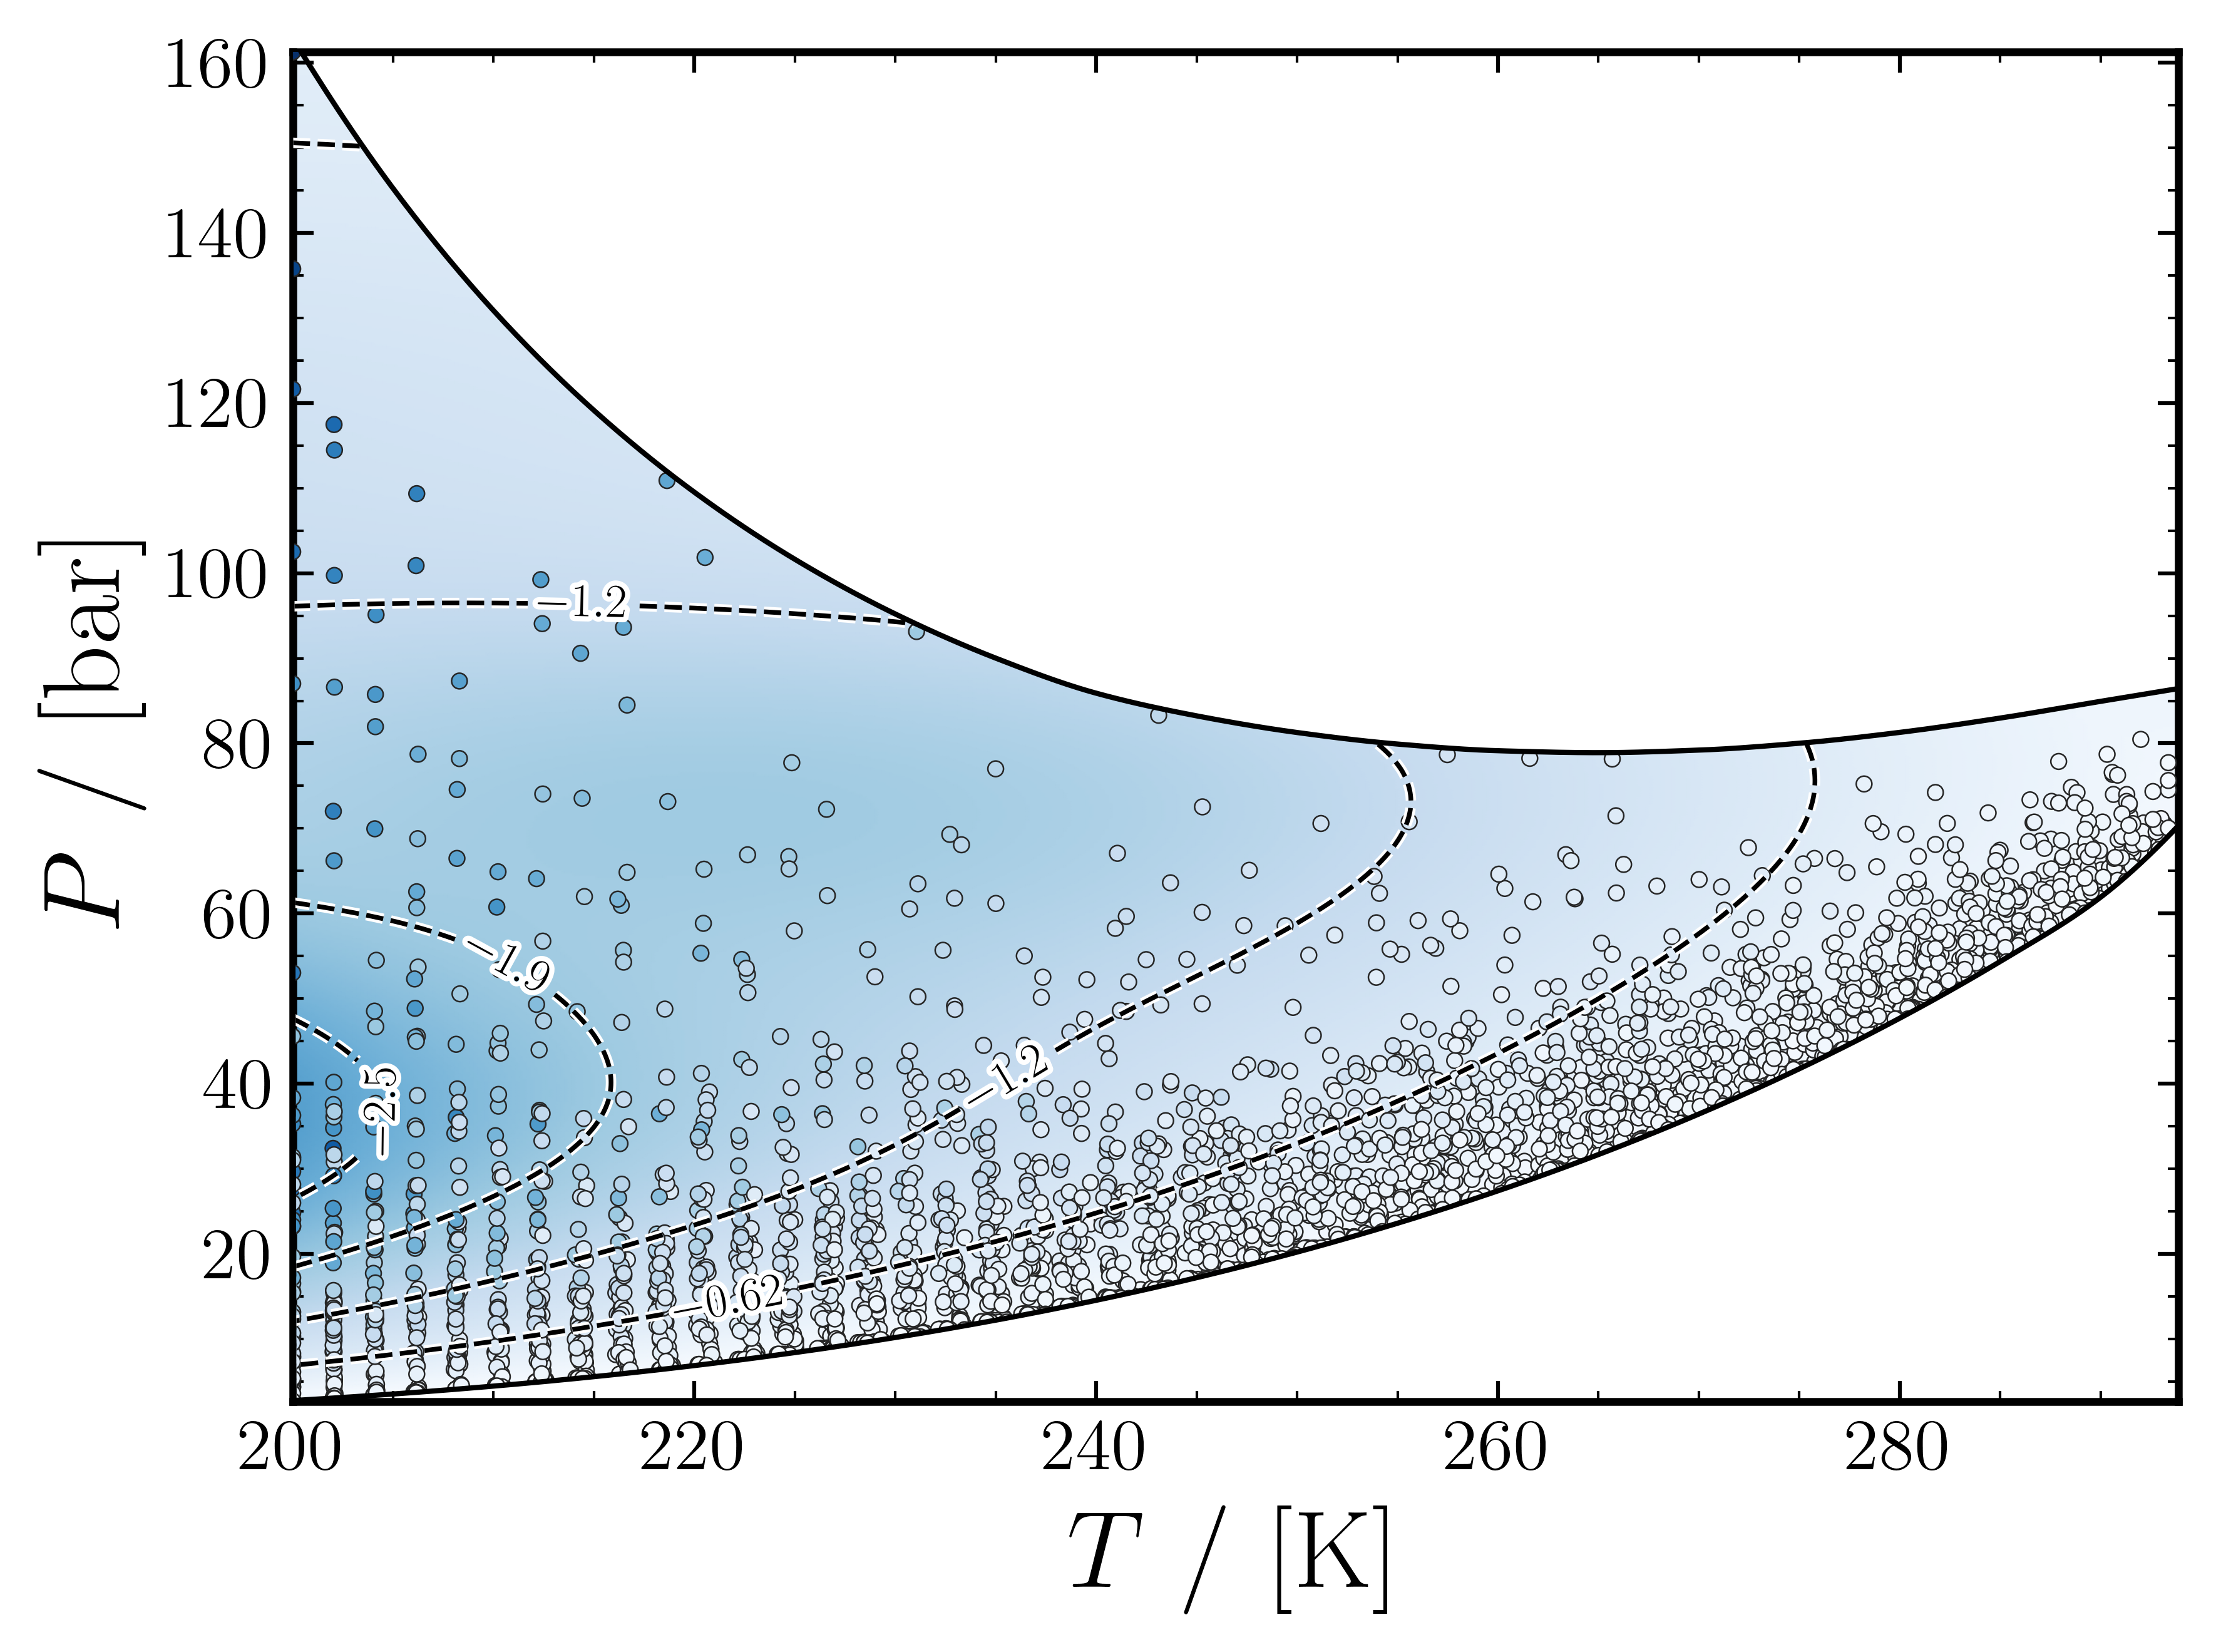

In [9]:
# (a) predicted-mean surface + training points coloured by ACTUAL Delta-gamma
render(Z_mean, Zc_mean, "Blues_r", -5.0, 0.0,
       r"$\langle\Delta\gamma\rangle\ /\ [\mathrm{mN}\,\mathrm{m}^{-1}]$",
       "Figure11a_GPR_mean", ticks=[-4, -3, -2, -1], extend="both",
       pts_vals=y_train.values, show_cbar=False)

actual sigma range: [0.010, 2.441]  (shared scale 0..2.5)


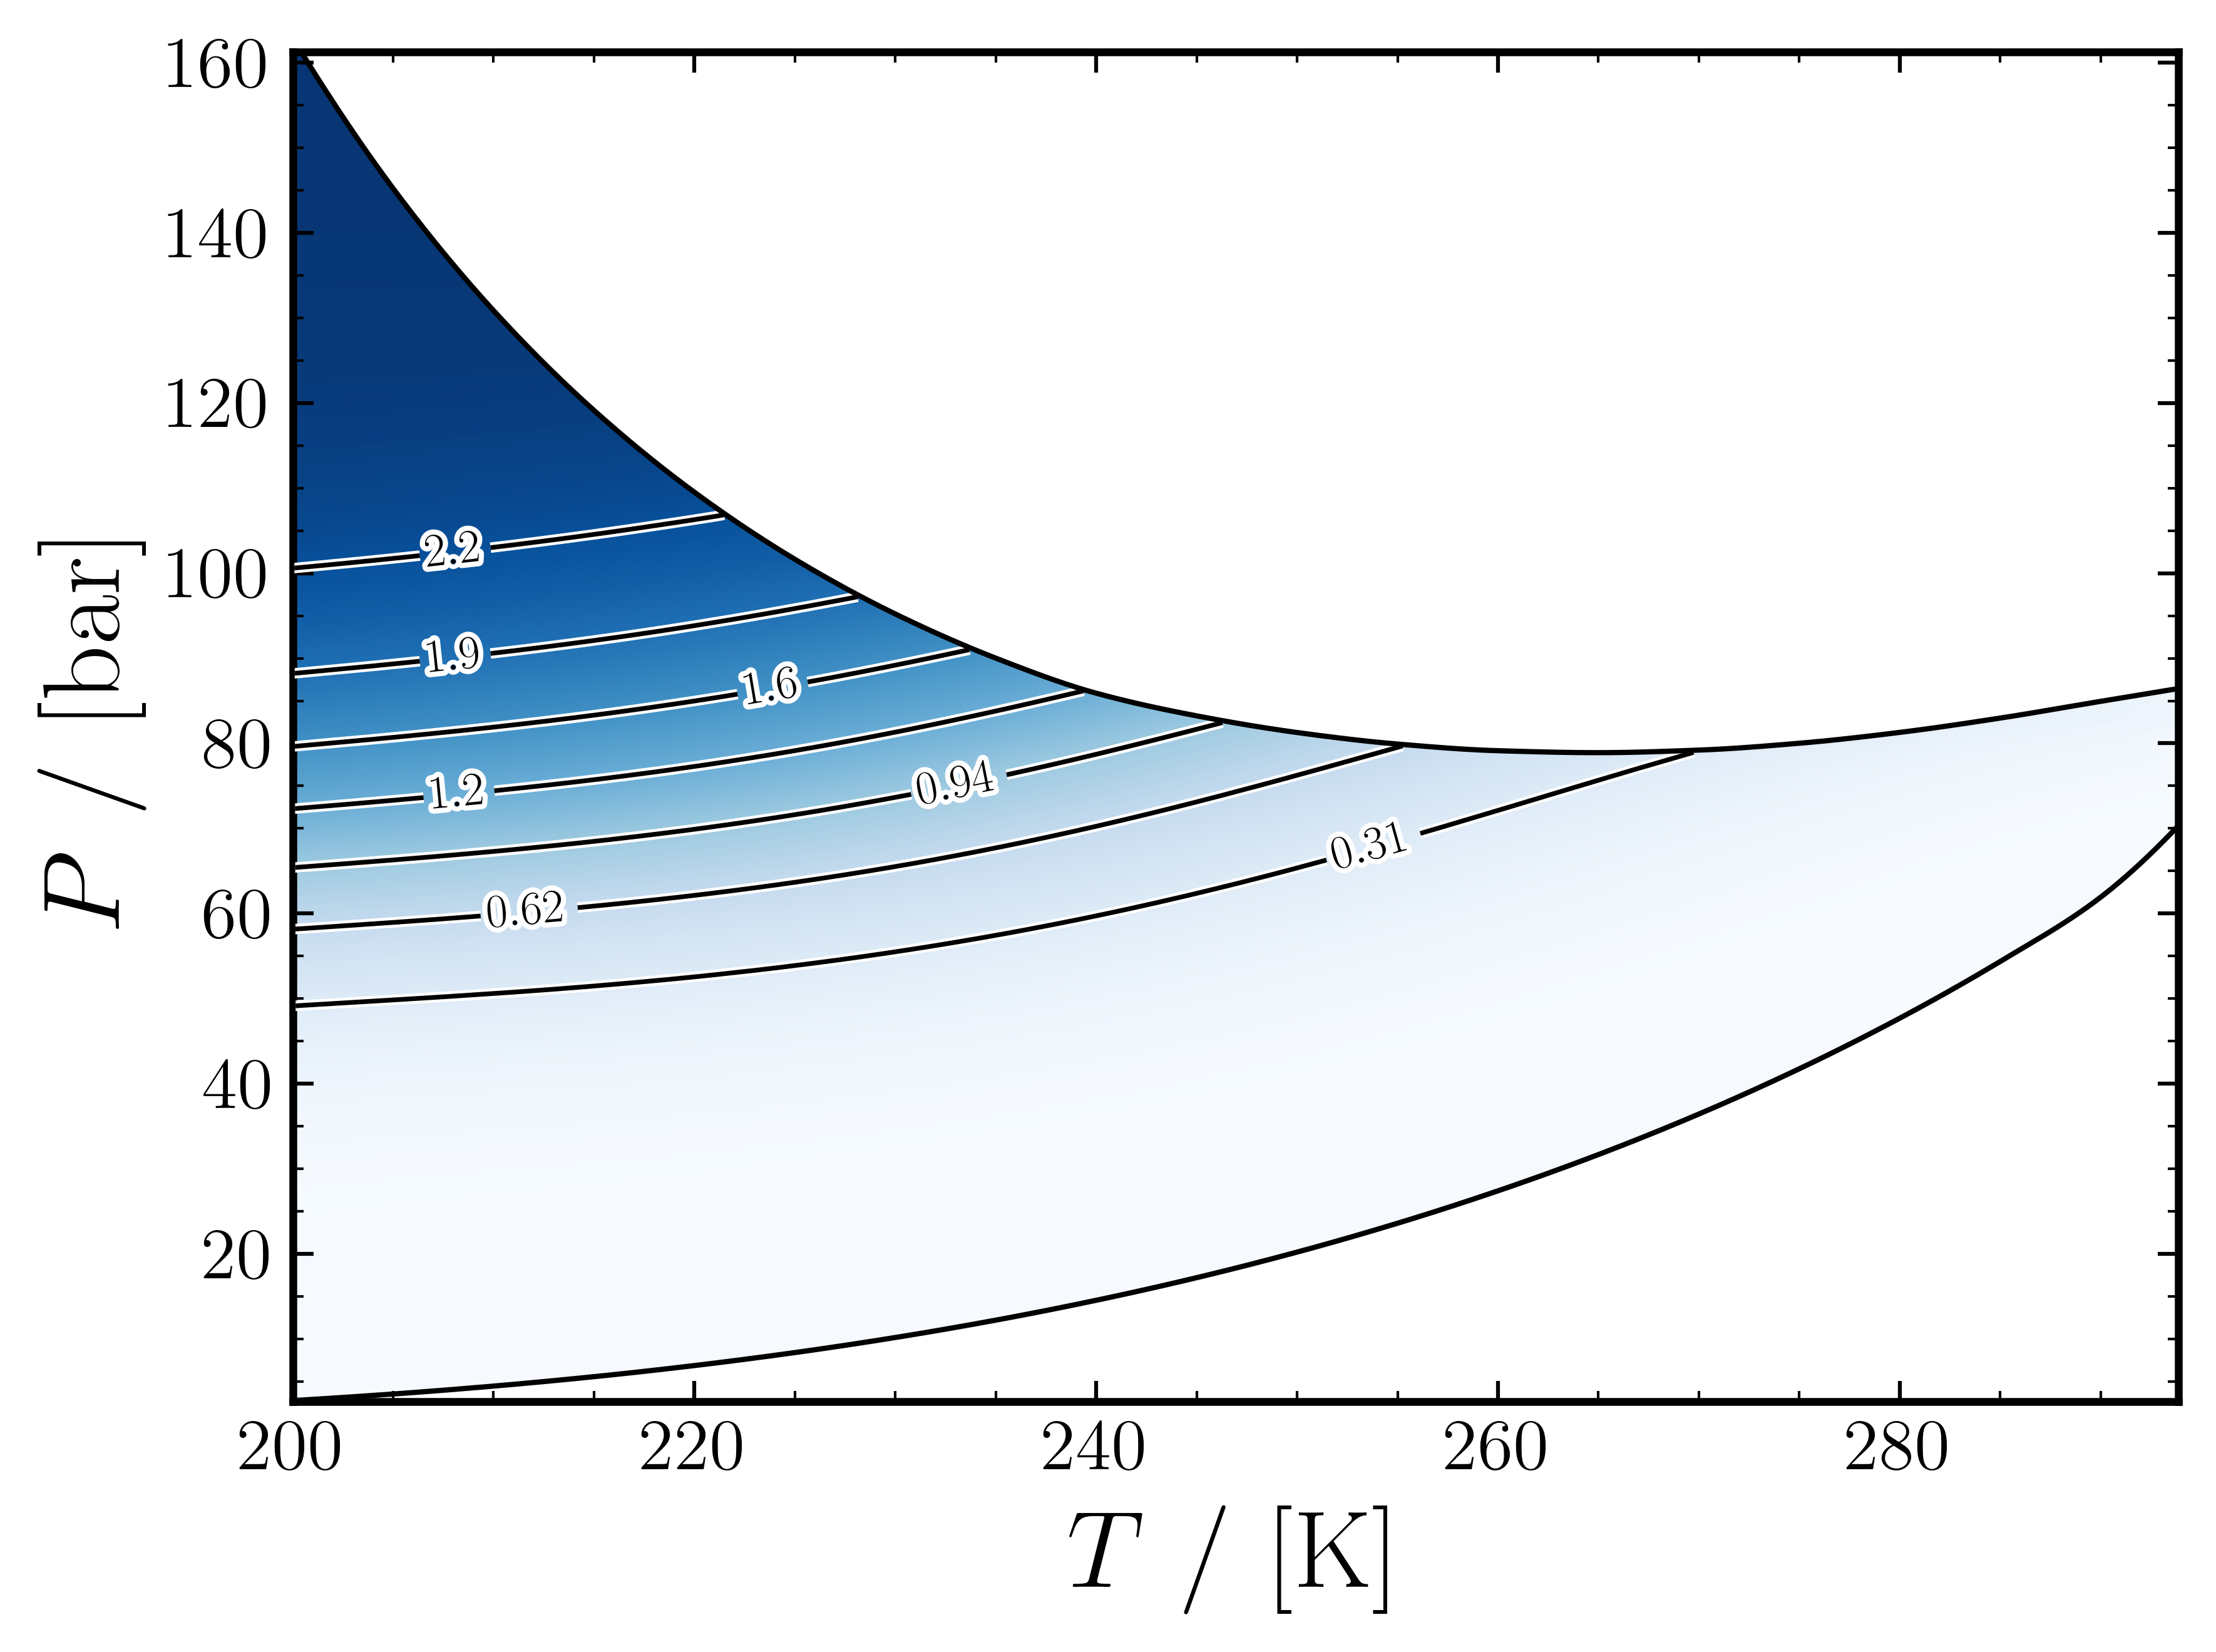

In [10]:
# (b) sigma (STD) surface — SHARED scale across GPR & SVGP (see SIGMA_VMAX)
svmin, svmax = float(np.nanmin(Zc_std)), float(np.nanmax(Zc_std))
print(f"actual sigma range: [{svmin:.3f}, {svmax:.3f}]  (shared scale 0..{SIGMA_VMAX})")
render(Z_std, Zc_std, STD_CMAP, SIGMA_VMIN, SIGMA_VMAX,
       r"$\sigma_{\Delta\gamma}\ /\ [\mathrm{mN}\,\mathrm{m}^{-1}]$",
       "Figure11b_GPR_std", extend="max", show_cbar=False)